<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/3D_Cow_CFD_Visualization_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# Install necessary libraries
!uv pip install -q "numpy>=2.3.5,<2.4" pyfr cupy-cuda12x trimesh matplotlib rtree embreex "k3d==2.17.0" ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Alternative installation script
# !uv pip install git+https://github.com/PyFR/PyFR.git k3d cupy-cuda12x trimesh numpy matplotlib ipython rtree

In [7]:
"""Render GPU potential flow around a cow mesh with PyFR and K3D.

PyFR supplies the native simulation configuration structure. CuPy evaluates
the Cartesian GPU potential-flow approximation, Trimesh supplies the imported
three-dimensional boundary representation, and K3D renders the resulting mesh
and velocity-colored streamlines interactively in Google Colab.
"""

from __future__ import annotations

import html
import importlib.metadata
import pathlib
import urllib.request
from dataclasses import dataclass

import cupy as cp
import cupyx.scipy.ndimage as gpu_ndimage
import k3d
import matplotlib.pyplot as plt
import numpy as np
import trimesh
from IPython.display import HTML, display
from k3d.colormaps import matplotlib_color_maps
from pyfr.inifile import Inifile
from trimesh.voxel import VoxelGrid
from trimesh.voxel.encoding import DenseEncoding
from trimesh.voxel.ops import fill_voxelization


# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
MESH_URL = (
    "https://raw.githubusercontent.com/alecjacobson/"
    "common-3d-test-models/master/data/cow.obj"
)
MESH_FILE = "/content/cow.obj"

FLOW_VELOCITY = 1.5
COW_SCALE = 2.0

# Model rotation controls are expressed in DEGREES.
ROTATION_X_DEG = 90.0
ROTATION_Y_DEG = 0.0
ROTATION_Z_DEG = 0.0

# Rotation application order.
# The transformation below applies X first, Y second, and Z third.
ROTATION_ORDER = "XYZ"

GRID_SHAPE = (80, 64, 56)
POTENTIAL_ITERATIONS = 900
JACOBI_RELAXATION = 0.92

INTEGRATION_STEPS = 500
TIME_STEP = 0.045

MIN_DOMAIN_LENGTH_X = 36.0
MIN_DOMAIN_SPAN_Y = 20.0
MIN_DOMAIN_SPAN_Z = 14.0

DOMAIN_PADDING_X = 7.0
DOMAIN_PADDING_Y = 4.0
DOMAIN_PADDING_Z = 4.0

VOXEL_PITCH_SCALE = 0.65
SOLID_DILATION_CELLS = 1

STREAMLINE_DENSITY_Y = 20
STREAMLINE_DENSITY_Z = 14
STREAMLINE_SEED_MARGIN = 0.82
STREAMLINE_MINIMUM_SPEED = 0.01

K3D_HEIGHT = 720
K3D_LINE_WIDTH = 0.045
K3D_RENDER_STRIDE = 1

# Initial camera controls.
CAMERA_DISTANCE_SCALE = 1.55
CAMERA_X_OFFSET_SCALE = 0.15
CAMERA_Z_OFFSET_SCALE = 0.15

DISPLAY_K3D_WIDGET = True
DISPLAY_K3D_SNAPSHOT_FALLBACK = True

PLOT_DPI = 250
# ---------------------------------------------------


plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]


@dataclass(frozen=True)
class GridSpec:
    """Store the Cartesian wind-tunnel discretization."""

    x: np.ndarray
    y: np.ndarray
    z: np.ndarray

    @property
    def shape(self) -> tuple[int, int, int]:
        """Return the number of grid points along each Cartesian axis."""
        return (
            self.x.size,
            self.y.size,
            self.z.size,
        )

    @property
    def dx(self) -> float:
        """Return the longitudinal grid spacing."""
        return float(self.x[1] - self.x[0])

    @property
    def dy(self) -> float:
        """Return the lateral grid spacing."""
        return float(self.y[1] - self.y[0])

    @property
    def dz(self) -> float:
        """Return the vertical grid spacing."""
        return float(self.z[1] - self.z[0])

    @property
    def spacing(self) -> tuple[float, float, float]:
        """Return all Cartesian grid spacings."""
        return (
            self.dx,
            self.dy,
            self.dz,
        )

    @property
    def bounds(
        self,
    ) -> tuple[
        float,
        float,
        float,
        float,
        float,
        float,
    ]:
        """Return K3D-compatible physical scene bounds."""
        return (
            float(self.x[0]),
            float(self.y[0]),
            float(self.z[0]),
            float(self.x[-1]),
            float(self.y[-1]),
            float(self.z[-1]),
        )


def configure_colab_k3d() -> None:
    """Enable K3D rendering inside Google Colab."""
    from google.colab import output

    output.enable_custom_widget_manager()
    k3d.switch_to_text_protocol()


def build_pyfr_config() -> Inifile:
    """Construct simulation settings with PyFR's native INI structure."""
    config = Inifile()

    config.set(
        "backend",
        "precision",
        "single",
    )
    config.set(
        "backend-cuda",
        "device-id",
        0,
    )
    config.set(
        "backend-cuda",
        "mpi-type",
        "standard",
    )

    config.set(
        "constants",
        "velocity",
        FLOW_VELOCITY,
    )
    config.set(
        "constants",
        "steps",
        INTEGRATION_STEPS,
    )
    config.set(
        "constants",
        "dt",
        TIME_STEP,
    )

    return config


def report_runtime(config: Inifile) -> None:
    """Report package, GPU, and PyFR runtime information."""
    device_count = cp.cuda.runtime.getDeviceCount()

    if device_count < 1:
        raise RuntimeError(
            "No CUDA GPU was detected. Select an L4 GPU runtime."
        )

    cp.cuda.Device(0).use()

    properties = cp.cuda.runtime.getDeviceProperties(0)
    gpu_name = properties.get(
        "name",
        "Unknown CUDA GPU",
    )

    if isinstance(gpu_name, bytes):
        gpu_name = gpu_name.decode(
            "utf-8",
            errors="replace",
        )

    print(f"CUDA GPU: {gpu_name}")
    print(
        "PyFR:",
        importlib.metadata.version("pyfr"),
    )
    print(
        "NumPy:",
        np.__version__,
    )
    print(
        "CuPy:",
        cp.__version__,
    )
    print(
        "Trimesh:",
        trimesh.__version__,
    )
    print(
        "K3D:",
        k3d.__version__,
    )
    print(
        "PyFR CUDA device:",
        config.get(
            "backend-cuda",
            "device-id",
        ),
    )


def build_rotation_matrix() -> np.ndarray:
    """Construct the deterministic model rotation matrix.

    The public controls are specified in degrees. Each angle is converted
    exactly once to radians before constructing the corresponding homogeneous
    rotation matrix.

    Returns:
        Four-by-four homogeneous model transformation matrix.
    """
    rotation_x_rad = np.deg2rad(
        ROTATION_X_DEG
    )
    rotation_y_rad = np.deg2rad(
        ROTATION_Y_DEG
    )
    rotation_z_rad = np.deg2rad(
        ROTATION_Z_DEG
    )

    rotation_x = trimesh.transformations.rotation_matrix(
        rotation_x_rad,
        [1.0, 0.0, 0.0],
    )

    rotation_y = trimesh.transformations.rotation_matrix(
        rotation_y_rad,
        [0.0, 1.0, 0.0],
    )

    rotation_z = trimesh.transformations.rotation_matrix(
        rotation_z_rad,
        [0.0, 0.0, 1.0],
    )

    if ROTATION_ORDER == "XYZ":
        # Matrix multiplication acts right-to-left on homogeneous vectors.
        # Therefore X is applied first, then Y, followed by Z.
        rotation = (
            rotation_z
            @ rotation_y
            @ rotation_x
        )
    else:
        raise ValueError(
            f"Unsupported rotation order: {ROTATION_ORDER}"
        )

    return np.asarray(
        rotation,
        dtype=np.float64,
    )


def fetch_and_transform_mesh(
    url: str,
) -> trimesh.Trimesh:
    """Download, center, rotate, and scale the cow mesh.

    Args:
        url: URL containing the source OBJ file.

    Returns:
        Processed triangular mesh with deterministic orientation.
    """
    mesh_path = pathlib.Path(
        MESH_FILE
    )

    urllib.request.urlretrieve(
        url,
        mesh_path,
    )

    loaded = trimesh.load(
        mesh_path,
        force="mesh",
        process=True,
    )

    if isinstance(
        loaded,
        trimesh.Scene,
    ):
        geometries = tuple(
            loaded.geometry.values()
        )

        if len(geometries) == 0:
            raise RuntimeError(
                "The downloaded OBJ contains zero mesh geometries."
            )

        mesh = trimesh.util.concatenate(
            geometries
        )
    else:
        mesh = loaded

    if (
        isinstance(
            mesh,
            trimesh.Trimesh,
        )
        is False
        or mesh.is_empty
    ):
        raise RuntimeError(
            "The downloaded OBJ failed to produce a triangular mesh."
        )

    mesh = mesh.copy()
    mesh.remove_unreferenced_vertices()

    # Place the unrotated object exactly at the world origin.
    original_center = mesh.bounds.mean(
        axis=0
    )

    mesh.apply_translation(
        -original_center
    )

    rotation_matrix = (
        build_rotation_matrix()
    )

    mesh.apply_transform(
        rotation_matrix
    )

    mesh.apply_scale(
        COW_SCALE
    )

    # Recenter after rotation and scale so the wind tunnel stays symmetric.
    transformed_center = mesh.bounds.mean(
        axis=0
    )

    mesh.apply_translation(
        -transformed_center
    )

    vertices = np.asarray(
        mesh.vertices,
        dtype=np.float64,
    )

    if np.isfinite(
        vertices
    ).all() is False:
        raise RuntimeError(
            "The transformed cow mesh contains invalid coordinates."
        )

    print(
        f"Mesh: {len(mesh.vertices):,} vertices, "
        f"{len(mesh.faces):,} triangles"
    )

    print(
        "Applied mesh rotation: "
        f"X={ROTATION_X_DEG:.3f}°, "
        f"Y={ROTATION_Y_DEG:.3f}°, "
        f"Z={ROTATION_Z_DEG:.3f}°"
    )

    print(
        "Internal radians: "
        f"X={np.deg2rad(ROTATION_X_DEG):.6f}, "
        f"Y={np.deg2rad(ROTATION_Y_DEG):.6f}, "
        f"Z={np.deg2rad(ROTATION_Z_DEG):.6f}"
    )

    print(
        "Mesh center:",
        np.round(
            mesh.bounds.mean(axis=0),
            8,
        ),
    )

    print(
        "Mesh extents after rotation:",
        np.round(
            mesh.extents,
            3,
        ),
    )

    return mesh


def build_grid(
    mesh: trimesh.Trimesh,
) -> GridSpec:
    """Build a mesh-aware wind-tunnel domain.

    Args:
        mesh: Imported cow boundary representation.

    Returns:
        Cartesian wind-tunnel grid.
    """
    (
        extent_x,
        extent_y,
        extent_z,
    ) = np.asarray(
        mesh.extents,
        dtype=np.float64,
    )

    domain_length_x = max(
        MIN_DOMAIN_LENGTH_X,
        float(
            extent_x
            + 2.0 * DOMAIN_PADDING_X
        ),
    )

    domain_span_y = max(
        MIN_DOMAIN_SPAN_Y,
        float(
            extent_y
            + 2.0 * DOMAIN_PADDING_Y
        ),
    )

    domain_span_z = max(
        MIN_DOMAIN_SPAN_Z,
        float(
            extent_z
            + 2.0 * DOMAIN_PADDING_Z
        ),
    )

    nx, ny, nz = GRID_SHAPE

    x = np.linspace(
        -0.5 * domain_length_x,
        0.5 * domain_length_x,
        nx,
        dtype=np.float32,
    )

    y = np.linspace(
        -0.5 * domain_span_y,
        0.5 * domain_span_y,
        ny,
        dtype=np.float32,
    )

    z = np.linspace(
        -0.5 * domain_span_z,
        0.5 * domain_span_z,
        nz,
        dtype=np.float32,
    )

    grid = GridSpec(
        x=x,
        y=y,
        z=z,
    )

    print(
        "Wind tunnel: "
        f"{domain_length_x:.3f} × "
        f"{domain_span_y:.3f} × "
        f"{domain_span_z:.3f}"
    )

    print(
        "Grid: "
        f"{grid.shape[0]} × "
        f"{grid.shape[1]} × "
        f"{grid.shape[2]}"
    )

    print(
        "Spacing: "
        f"dx={grid.dx:.4f}, "
        f"dy={grid.dy:.4f}, "
        f"dz={grid.dz:.4f}"
    )

    return grid


def dilate_mask(
    mask: np.ndarray,
    iterations: int,
) -> np.ndarray:
    """Dilate a Boolean solid mask using six-connected neighbors.

    Args:
        mask: Initial voxel occupancy.
        iterations: Number of dilation iterations.

    Returns:
        Dilated occupancy mask.
    """
    result = np.asarray(
        mask,
        dtype=bool,
    ).copy()

    for _ in range(
        max(0, iterations)
    ):
        source = result
        expanded = source.copy()

        expanded[
            1:,
            :,
            :,
        ] |= source[
            :-1,
            :,
            :,
        ]

        expanded[
            :-1,
            :,
            :,
        ] |= source[
            1:,
            :,
            :,
        ]

        expanded[
            :,
            1:,
            :,
        ] |= source[
            :,
            :-1,
            :,
        ]

        expanded[
            :,
            :-1,
            :,
        ] |= source[
            :,
            1:,
            :,
        ]

        expanded[
            :,
            :,
            1:,
        ] |= source[
            :,
            :,
            :-1,
        ]

        expanded[
            :,
            :,
            :-1,
        ] |= source[
            :,
            :,
            1:,
        ]

        result = expanded

    return result


def create_solid_mask(
    mesh: trimesh.Trimesh,
    grid: GridSpec,
) -> np.ndarray:
    """Voxelize and fill the complete cow volume.

    Args:
        mesh: Cow triangular surface mesh.
        grid: Cartesian CFD grid.

    Returns:
        Boolean occupancy mask on the CFD grid.
    """
    pitch = (
        VOXEL_PITCH_SCALE
        * min(grid.spacing)
    )

    print(
        f"Voxelizing cow at pitch {pitch:.4f}..."
    )

    surface_voxels = mesh.voxelized(
        pitch=pitch,
        method="subdivide",
    )

    filled_indices = (
        fill_voxelization(
            surface_voxels.sparse_indices
        )
    )

    voxel_shape = tuple(
        int(value)
        for value in surface_voxels.shape
    )

    dense = np.zeros(
        voxel_shape,
        dtype=bool,
    )

    valid = (
        np.all(
            filled_indices >= 0,
            axis=1,
        )
        & np.all(
            filled_indices
            < np.asarray(
                voxel_shape
            ),
            axis=1,
        )
    )

    filled_indices = (
        filled_indices[valid]
    )

    dense[
        tuple(
            filled_indices.T
        )
    ] = True

    filled_voxels = VoxelGrid(
        DenseEncoding(
            dense
        ),
        transform=np.asarray(
            surface_voxels.transform
        ),
    )

    (
        x_grid,
        y_grid,
        z_grid,
    ) = np.meshgrid(
        grid.x,
        grid.y,
        grid.z,
        indexing="ij",
    )

    query_points = np.column_stack(
        (
            x_grid.ravel(),
            y_grid.ravel(),
            z_grid.ravel(),
        )
    )

    solid = filled_voxels.is_filled(
        query_points
    ).reshape(
        grid.shape
    )

    solid = dilate_mask(
        solid,
        SOLID_DILATION_CELLS,
    )

    solid_cells = int(
        np.count_nonzero(
            solid
        )
    )

    if solid_cells == 0:
        raise RuntimeError(
            "Cow voxelization generated zero occupied cells."
        )

    boundary_contact = (
        np.any(solid[0, :, :])
        or np.any(solid[-1, :, :])
        or np.any(solid[:, 0, :])
        or np.any(solid[:, -1, :])
        or np.any(solid[:, :, 0])
        or np.any(solid[:, :, -1])
    )

    if boundary_contact:
        raise RuntimeError(
            "Automatic wind-tunnel sizing failed to clear the cow mesh."
        )

    print(
        f"Solid mask: {solid_cells:,} cells "
        f"({100.0 * solid.mean():.3f}% of domain)"
    )

    return solid


def solve_velocity_potential(
    solid_cpu: np.ndarray,
    grid: GridSpec,
    config: Inifile,
) -> cp.ndarray:
    """Solve the three-dimensional velocity potential using CUDA.

    Args:
        solid_cpu: CPU cow occupancy mask.
        grid: Cartesian simulation grid.
        config: PyFR-native configuration.

    Returns:
        GPU velocity field with shape ``(3, nx, ny, nz)``.
    """
    free_stream_velocity = (
        config.getfloat(
            "constants",
            "velocity",
        )
    )

    solid = cp.asarray(
        solid_cpu,
        dtype=cp.bool_,
    )

    x_gpu = cp.asarray(
        grid.x,
        dtype=cp.float32,
    )[:, None, None]

    potential = cp.broadcast_to(
        free_stream_velocity
        * x_gpu,
        grid.shape,
    ).copy()

    weight_x = (
        1.0
        / grid.dx**2
    )
    weight_y = (
        1.0
        / grid.dy**2
    )
    weight_z = (
        1.0
        / grid.dz**2
    )

    denominator = (
        2.0
        * (
            weight_x
            + weight_y
            + weight_z
        )
    )

    print(
        "Solving velocity potential on CUDA..."
    )

    for iteration in range(
        1,
        POTENTIAL_ITERATIONS + 1,
    ):
        center = potential[
            1:-1,
            1:-1,
            1:-1,
        ]

        x_minus = cp.where(
            solid[
                :-2,
                1:-1,
                1:-1,
            ],
            center,
            potential[
                :-2,
                1:-1,
                1:-1,
            ],
        )

        x_plus = cp.where(
            solid[
                2:,
                1:-1,
                1:-1,
            ],
            center,
            potential[
                2:,
                1:-1,
                1:-1,
            ],
        )

        y_minus = cp.where(
            solid[
                1:-1,
                :-2,
                1:-1,
            ],
            center,
            potential[
                1:-1,
                :-2,
                1:-1,
            ],
        )

        y_plus = cp.where(
            solid[
                1:-1,
                2:,
                1:-1,
            ],
            center,
            potential[
                1:-1,
                2:,
                1:-1,
            ],
        )

        z_minus = cp.where(
            solid[
                1:-1,
                1:-1,
                :-2,
            ],
            center,
            potential[
                1:-1,
                1:-1,
                :-2,
            ],
        )

        z_plus = cp.where(
            solid[
                1:-1,
                1:-1,
                2:,
            ],
            center,
            potential[
                1:-1,
                1:-1,
                2:,
            ],
        )

        jacobi_value = (
            weight_x
            * (
                x_minus
                + x_plus
            )
            + weight_y
            * (
                y_minus
                + y_plus
            )
            + weight_z
            * (
                z_minus
                + z_plus
            )
        ) / denominator

        relaxed = (
            (
                1.0
                - JACOBI_RELAXATION
            )
            * center
            + JACOBI_RELAXATION
            * jacobi_value
        )

        updated = (
            potential.copy()
        )

        updated[
            1:-1,
            1:-1,
            1:-1,
        ] = cp.where(
            solid[
                1:-1,
                1:-1,
                1:-1,
            ],
            center,
            relaxed,
        )

        # Longitudinal free-stream boundary conditions.
        updated[
            0,
            :,
            :,
        ] = (
            float(
                grid.x[0]
            )
            * free_stream_velocity
        )

        updated[
            -1,
            :,
            :,
        ] = (
            float(
                grid.x[-1]
            )
            * free_stream_velocity
        )

        # Transverse slip boundary conditions.
        updated[
            :,
            0,
            :,
        ] = updated[
            :,
            1,
            :,
        ]

        updated[
            :,
            -1,
            :,
        ] = updated[
            :,
            -2,
            :,
        ]

        updated[
            :,
            :,
            0,
        ] = updated[
            :,
            :,
            1,
        ]

        updated[
            :,
            :,
            -1,
        ] = updated[
            :,
            :,
            -2,
        ]

        potential = updated

        if (
            iteration == 1
            or iteration % 100 == 0
            or iteration
            == POTENTIAL_ITERATIONS
        ):
            print(
                "Potential iteration "
                f"{iteration:4d}/"
                f"{POTENTIAL_ITERATIONS}"
            )

    (
        velocity_x,
        velocity_y,
        velocity_z,
    ) = cp.gradient(
        potential,
        grid.dx,
        grid.dy,
        grid.dz,
        edge_order=1,
    )

    velocity_x = cp.where(
        solid,
        0.0,
        velocity_x,
    )

    velocity_y = cp.where(
        solid,
        0.0,
        velocity_y,
    )

    velocity_z = cp.where(
        solid,
        0.0,
        velocity_z,
    )

    velocity = cp.stack(
        (
            velocity_x,
            velocity_y,
            velocity_z,
        ),
        axis=0,
    ).astype(
        cp.float32
    )

    cp.cuda.runtime.deviceSynchronize()

    print(
        "Velocity field completed."
    )

    return velocity


def physical_to_grid_coordinates(
    positions: cp.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Convert physical coordinates to fractional array coordinates.

    Args:
        positions: Particle positions with shape ``(N, 3)``.
        grid: Cartesian CFD grid.

    Returns:
        Coordinate matrix compatible with ``map_coordinates``.
    """
    index_x = (
        positions[:, 0]
        - float(grid.x[0])
    ) / grid.dx

    index_y = (
        positions[:, 1]
        - float(grid.y[0])
    ) / grid.dy

    index_z = (
        positions[:, 2]
        - float(grid.z[0])
    ) / grid.dz

    return cp.stack(
        (
            index_x,
            index_y,
            index_z,
        ),
        axis=0,
    )


def sample_velocity(
    velocity: cp.ndarray,
    positions: cp.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Trilinearly interpolate the GPU velocity field.

    Args:
        velocity: Velocity array with shape ``(3, nx, ny, nz)``.
        positions: Physical particle positions.
        grid: Cartesian CFD grid.

    Returns:
        Interpolated velocity vectors.
    """
    coordinates = (
        physical_to_grid_coordinates(
            positions,
            grid,
        )
    )

    components = [
        gpu_ndimage.map_coordinates(
            velocity[axis],
            coordinates,
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False,
        )
        for axis in range(3)
    ]

    return cp.stack(
        components,
        axis=1,
    )


def sample_solid(
    solid: cp.ndarray,
    positions: cp.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Evaluate solid occupancy at physical particle positions.

    Args:
        solid: Boolean solid mask.
        positions: Particle coordinates.
        grid: Cartesian CFD grid.

    Returns:
        Boolean collision state for every particle.
    """
    coordinates = (
        physical_to_grid_coordinates(
            positions,
            grid,
        )
    )

    occupancy = (
        gpu_ndimage.map_coordinates(
            solid.astype(
                cp.float32
            ),
            coordinates,
            order=0,
            mode="constant",
            cval=1.0,
            prefilter=False,
        )
    )

    return occupancy > 0.5


def integrate_streamlines(
    velocity: cp.ndarray,
    solid_cpu: np.ndarray,
    grid: GridSpec,
    config: Inifile,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:
    """Integrate three-dimensional streamlines with midpoint RK2.

    Args:
        velocity: GPU velocity vector field.
        solid_cpu: CPU cow occupancy mask.
        grid: Cartesian simulation grid.
        config: PyFR configuration.

    Returns:
        Streamline coordinates and velocity magnitudes.
    """
    steps = config.getint(
        "constants",
        "steps",
    )

    dt = config.getfloat(
        "constants",
        "dt",
    )

    solid = cp.asarray(
        solid_cpu,
        dtype=cp.bool_,
    )

    y_limit = (
        STREAMLINE_SEED_MARGIN
        * min(
            abs(
                float(
                    grid.y[0]
                )
            ),
            abs(
                float(
                    grid.y[-1]
                )
            ),
        )
    )

    z_limit = (
        STREAMLINE_SEED_MARGIN
        * min(
            abs(
                float(
                    grid.z[0]
                )
            ),
            abs(
                float(
                    grid.z[-1]
                )
            ),
        )
    )

    y_values = cp.linspace(
        -y_limit,
        y_limit,
        STREAMLINE_DENSITY_Y,
        dtype=cp.float32,
    )

    z_values = cp.linspace(
        -z_limit,
        z_limit,
        STREAMLINE_DENSITY_Z,
        dtype=cp.float32,
    )

    (
        y_seed,
        z_seed,
    ) = cp.meshgrid(
        y_values,
        z_values,
        indexing="ij",
    )

    x_seed = cp.full_like(
        y_seed,
        float(
            grid.x[1]
        ),
    )

    seeds = cp.stack(
        (
            x_seed.ravel(),
            y_seed.ravel(),
            z_seed.ravel(),
        ),
        axis=1,
    )

    particle_count = int(
        seeds.shape[0]
    )

    trajectories = cp.full(
        (
            particle_count,
            steps,
            3,
        ),
        cp.nan,
        dtype=cp.float32,
    )

    speeds = cp.full(
        (
            particle_count,
            steps,
        ),
        cp.nan,
        dtype=cp.float32,
    )

    trajectories[
        :,
        0,
        :,
    ] = seeds

    initial_velocity = (
        sample_velocity(
            velocity,
            seeds,
            grid,
        )
    )

    speeds[
        :,
        0,
    ] = cp.linalg.norm(
        initial_velocity,
        axis=1,
    )

    active = cp.ones(
        particle_count,
        dtype=cp.bool_,
    )

    x_min = float(
        grid.x[0]
    )
    x_max = float(
        grid.x[-1]
    )
    y_min = float(
        grid.y[0]
    )
    y_max = float(
        grid.y[-1]
    )
    z_min = float(
        grid.z[0]
    )
    z_max = float(
        grid.z[-1]
    )

    print(
        f"Integrating "
        f"{particle_count:,} "
        "streamlines..."
    )

    completed_steps = 1

    for step in range(
        1,
        steps,
    ):
        previous = cp.where(
            active[:, None],
            trajectories[
                :,
                step - 1,
                :,
            ],
            seeds,
        )

        velocity_1 = (
            sample_velocity(
                velocity,
                previous,
                grid,
            )
        )

        midpoint = (
            previous
            + 0.5
            * dt
            * velocity_1
        )

        velocity_2 = (
            sample_velocity(
                velocity,
                midpoint,
                grid,
            )
        )

        candidate = (
            previous
            + dt
            * velocity_2
        )

        collision = (
            sample_solid(
                solid,
                candidate,
                grid,
            )
        )

        local_speed = cp.linalg.norm(
            velocity_2,
            axis=1,
        )

        finite = cp.all(
            cp.isfinite(
                candidate
            ),
            axis=1,
        )

        inside_domain = (
            (
                candidate[:, 0]
                > x_min
            )
            & (
                candidate[:, 0]
                < x_max
            )
            & (
                candidate[:, 1]
                > y_min
            )
            & (
                candidate[:, 1]
                < y_max
            )
            & (
                candidate[:, 2]
                > z_min
            )
            & (
                candidate[:, 2]
                < z_max
            )
        )

        moving = (
            local_speed
            > STREAMLINE_MINIMUM_SPEED
        )

        active = (
            active
            & finite
            & inside_domain
            & (
                collision
                == 0
            )
            & moving
        )

        trajectories[
            :,
            step,
            :,
        ] = cp.where(
            active[:, None],
            candidate,
            cp.nan,
        )

        speeds[
            :,
            step,
        ] = cp.where(
            active,
            local_speed,
            cp.nan,
        )

        completed_steps = (
            step
            + 1
        )

        if (
            bool(
                cp.any(
                    active
                ).get()
            )
            is False
        ):
            break

    print(
        "Streamline integration completed "
        f"after {completed_steps} levels."
    )

    return (
        cp.asnumpy(
            trajectories
        ),
        cp.asnumpy(
            speeds
        ),
    )


def pack_streamlines(
    streamlines: np.ndarray,
    speeds: np.ndarray,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Convert trajectories into indexed K3D line geometry.

    Args:
        streamlines: Streamline positions.
        speeds: Local velocity magnitudes.

    Returns:
        K3D vertices, segment indices, and scalar attributes.
    """
    vertex_parts: list[
        np.ndarray
    ] = []

    segment_parts: list[
        np.ndarray
    ] = []

    attribute_parts: list[
        np.ndarray
    ] = []

    vertex_offset = 0

    for (
        path,
        speed,
    ) in zip(
        streamlines,
        speeds,
        strict=True,
    ):
        valid = (
            np.isfinite(
                path
            ).all(
                axis=1
            )
            & np.isfinite(
                speed
            )
        )

        points = path[
            valid
        ]

        values = speed[
            valid
        ]

        if (
            K3D_RENDER_STRIDE
            > 1
        ):
            points = points[
                ::K3D_RENDER_STRIDE
            ]

            values = values[
                ::K3D_RENDER_STRIDE
            ]

        if (
            points.shape[0]
            < 2
        ):
            continue

        local_segments = (
            np.column_stack(
                (
                    np.arange(
                        points.shape[0]
                        - 1,
                        dtype=np.uint32,
                    ),
                    np.arange(
                        1,
                        points.shape[0],
                        dtype=np.uint32,
                    ),
                )
            )
        )

        points = (
            np.ascontiguousarray(
                points,
                dtype=np.float32,
            )
        )

        values = (
            np.ascontiguousarray(
                values,
                dtype=np.float32,
            )
        )

        vertex_parts.append(
            points
        )

        attribute_parts.append(
            values
        )

        segment_parts.append(
            local_segments
            + np.uint32(
                vertex_offset
            )
        )

        vertex_offset += (
            points.shape[0]
        )

    if (
        len(
            vertex_parts
        )
        == 0
    ):
        raise RuntimeError(
            "No valid streamline geometry reached K3D."
        )

    vertices = (
        np.ascontiguousarray(
            np.vstack(
                vertex_parts
            ),
            dtype=np.float32,
        )
    )

    segments = (
        np.ascontiguousarray(
            np.vstack(
                segment_parts
            ),
            dtype=np.uint32,
        )
    )

    attributes = (
        np.ascontiguousarray(
            np.concatenate(
                attribute_parts
            ),
            dtype=np.float32,
        )
    )

    if (
        np.isfinite(
            vertices
        ).all()
        is False
    ):
        raise RuntimeError(
            "K3D streamline vertices contain invalid values."
        )

    if (
        np.isfinite(
            attributes
        ).all()
        is False
    ):
        raise RuntimeError(
            "K3D streamline attributes contain invalid values."
        )

    return (
        vertices,
        segments,
        attributes,
    )


def generate_visualization(
    mesh: trimesh.Trimesh,
    streamlines: np.ndarray,
    speeds: np.ndarray,
    grid: GridSpec,
) -> k3d.Plot:
    """Construct the complete interactive K3D scene.

    Args:
        mesh: Cow triangular boundary representation.
        streamlines: Integrated streamline trajectories.
        speeds: Velocity magnitude along each streamline.
        grid: Cartesian simulation grid.

    Returns:
        Fully populated K3D scene.
    """
    mesh_vertices = (
        np.ascontiguousarray(
            mesh.vertices,
            dtype=np.float32,
        )
    )

    mesh_faces = (
        np.ascontiguousarray(
            mesh.faces,
            dtype=np.uint32,
        )
    )

    if (
        mesh_vertices.ndim
        != 2
        or mesh_vertices.shape[1]
        != 3
    ):
        raise RuntimeError(
            "Invalid K3D mesh vertex shape: "
            f"{mesh_vertices.shape}"
        )

    if (
        mesh_faces.ndim
        != 2
        or mesh_faces.shape[1]
        != 3
    ):
        raise RuntimeError(
            "Invalid K3D mesh face shape: "
            f"{mesh_faces.shape}"
        )

    if (
        np.isfinite(
            mesh_vertices
        ).all()
        is False
    ):
        raise RuntimeError(
            "Cow mesh contains invalid K3D coordinates."
        )

    (
        line_vertices,
        line_segments,
        line_attributes,
    ) = pack_streamlines(
        streamlines,
        speeds,
    )

    color_min = float(
        np.percentile(
            line_attributes,
            2.0,
        )
    )

    color_max = float(
        np.percentile(
            line_attributes,
            98.0,
        )
    )

    if (
        color_max
        <= color_min
    ):
        color_max = (
            color_min
            + 1.0e-6
        )

    (
        x_min,
        y_min,
        z_min,
        x_max,
        y_max,
        z_max,
    ) = grid.bounds

    center_x = (
        0.5
        * (
            x_min
            + x_max
        )
    )

    center_y = (
        0.5
        * (
            y_min
            + y_max
        )
    )

    center_z = (
        0.5
        * (
            z_min
            + z_max
        )
    )

    extent_x = (
        x_max
        - x_min
    )

    extent_y = (
        y_max
        - y_min
    )

    extent_z = (
        z_max
        - z_min
    )

    scene_extent = max(
        extent_x,
        extent_y,
        extent_z,
    )

    print(
        "K3D cow payload: "
        f"{mesh_vertices.shape[0]:,} vertices, "
        f"{mesh_faces.shape[0]:,} triangles"
    )

    print(
        "K3D streamline payload: "
        f"{line_vertices.shape[0]:,} vertices, "
        f"{line_segments.shape[0]:,} segments"
    )

    print(
        "K3D physical bounds: "
        f"x=[{x_min:.2f}, {x_max:.2f}], "
        f"y=[{y_min:.2f}, {y_max:.2f}], "
        f"z=[{z_min:.2f}, {z_max:.2f}]"
    )

    plot = k3d.plot(
        height=K3D_HEIGHT,
        antialias=3,
        background_color=0xF7F7F7,
        grid_color=0xC8C8C8,
        label_color=0x202020,
        grid=grid.bounds,
        grid_auto_fit=False,
        camera_auto_fit=False,
        grid_visible=True,
        camera_mode="orbit",
        camera_up_axis="z",
        axes=[
            "x",
            "y",
            "z",
        ],
        menu_visibility=True,
        auto_rendering=True,
        name=(
            "GPU flow around "
            "cow boundary"
        ),
    )

    cow_object = k3d.mesh(
        mesh_vertices,
        mesh_faces,
        color=0xA9A9A9,
        opacity=0.82,
        side="double",
        flat_shading=False,
        shininess=35.0,
        compression_level=0,
        name="Cow boundary",
    )

    streamline_object = (
        k3d.lines(
            line_vertices,
            line_segments,
            indices_type="segment",
            attribute=line_attributes,
            color_map=(
                matplotlib_color_maps.Viridis
            ),
            color_range=[
                color_min,
                color_max,
            ],
            width=K3D_LINE_WIDTH,
            shader="thick",
            shininess=20.0,
            compression_level=0,
            name=(
                "Velocity streamlines"
            ),
        )
    )

    plot += cow_object
    plot += streamline_object

    plot.colorbar_object_id = (
        streamline_object.id
    )

    # Fixed initial camera.
    #
    # This is deliberately separated from model orientation.
    # Changing the camera changes only the viewing direction.
    # ROTATION_X_DEG/Y/Z modify the physical mesh coordinates.
    plot.camera = [
        center_x
        + CAMERA_X_OFFSET_SCALE
        * scene_extent,
        center_y
        - CAMERA_DISTANCE_SCALE
        * scene_extent,
        center_z
        + CAMERA_Z_OFFSET_SCALE
        * scene_extent,
        center_x,
        center_y,
        center_z,
        0.0,
        0.0,
        1.0,
    ]

    print(
        "Initial camera position: "
        f"({plot.camera[0]:.3f}, "
        f"{plot.camera[1]:.3f}, "
        f"{plot.camera[2]:.3f})"
    )

    print(
        f"K3D objects attached: "
        f"{len(plot.objects)}"
    )

    for (
        index,
        plot_object,
    ) in enumerate(
        plot.objects,
        start=1,
    ):
        print(
            f"  {index}. "
            f"{plot_object.name}"
        )

    if (
        len(
            plot.objects
        )
        != 2
    ):
        raise RuntimeError(
            "The K3D scene did not receive both render objects."
        )

    return plot


def display_snapshot_fallback(
    plot: k3d.Plot,
) -> None:
    """Display an independent standalone K3D snapshot.

    Args:
        plot: Fully populated K3D scene.
    """
    snapshot = (
        plot.get_snapshot()
    )

    escaped_snapshot = (
        html.escape(
            snapshot,
            quote=True,
        )
    )

    iframe = (
        '<iframe '
        'style="width:100%;'
        f'height:{K3D_HEIGHT}px;'
        'border:0;" '
        f'srcdoc="{escaped_snapshot}">'
        "</iframe>"
    )

    print(
        "Rendering standalone K3D "
        "snapshot fallback..."
    )

    display(
        HTML(
            iframe
        )
    )


def execute_pipeline() -> k3d.Plot:
    """Execute geometry, CUDA flow, streamlines, and K3D rendering."""
    configure_colab_k3d()

    config = (
        build_pyfr_config()
    )

    report_runtime(
        config
    )

    print(
        "\nLoading cow boundary..."
    )

    geometry = (
        fetch_and_transform_mesh(
            MESH_URL
        )
    )

    print(
        "\nBuilding mesh-aware wind tunnel..."
    )

    grid = build_grid(
        geometry
    )

    print(
        "\nConstructing solid boundary mask..."
    )

    solid = create_solid_mask(
        geometry,
        grid,
    )

    print(
        "\nComputing GPU velocity field..."
    )

    velocity = (
        solve_velocity_potential(
            solid,
            grid,
            config,
        )
    )

    print(
        "\nIntegrating streamlines..."
    )

    (
        trajectories,
        speeds,
    ) = integrate_streamlines(
        velocity,
        solid,
        grid,
        config,
    )

    print(
        "\nConstructing K3D objects..."
    )

    scene = (
        generate_visualization(
            geometry,
            trajectories,
            speeds,
            grid,
        )
    )

    return scene


# ---------------------------------------------------
# EXECUTION
# ---------------------------------------------------
scene = execute_pipeline()

if DISPLAY_K3D_WIDGET:
    print(
        "\nRendering interactive "
        "K3D widget..."
    )
    scene.display()

if DISPLAY_K3D_SNAPSHOT_FALLBACK:
    display_snapshot_fallback(
        scene
    )

print(
    "\nRendering complete."
)

print(
    "Expected K3D objects: 2"
)

print(
    f"Actual K3D objects: "
    f"{len(scene.objects)}"
)

CUDA GPU: Tesla T4
PyFR: 2.1
NumPy: 2.0.2
CuPy: 14.0.1
Trimesh: 5.0.0
K3D: 2.17.0
PyFR CUDA device: 0

Loading cow boundary...
Mesh: 2,903 vertices, 5,804 triangles
Applied mesh rotation: X=90.000°, Y=0.000°, Z=0.000°
Internal radians: X=1.570796, Y=0.000000, Z=0.000000
Mesh center: [0. 0. 0.]
Mesh extents after rotation: [20.888  6.806 12.794]

Building mesh-aware wind tunnel...
Wind tunnel: 36.000 × 20.000 × 20.794
Grid: 80 × 64 × 56
Spacing: dx=0.4557, dy=0.3175, dz=0.3781

Constructing solid boundary mask...
Voxelizing cow at pitch 0.2063...
Solid mask: 12,231 cells (4.266% of domain)

Computing GPU velocity field...
Solving velocity potential on CUDA...
Potential iteration    1/900
Potential iteration  100/900
Potential iteration  200/900
Potential iteration  300/900
Potential iteration  400/900
Potential iteration  500/900
Potential iteration  600/900
Potential iteration  700/900
Potential iteration  800/900
Potential iteration  900/900
Velocity field completed.

Integrating stre

Output()

Rendering standalone K3D snapshot fallback...



Rendering complete.
Expected K3D objects: 2
Actual K3D objects: 2


Example result:

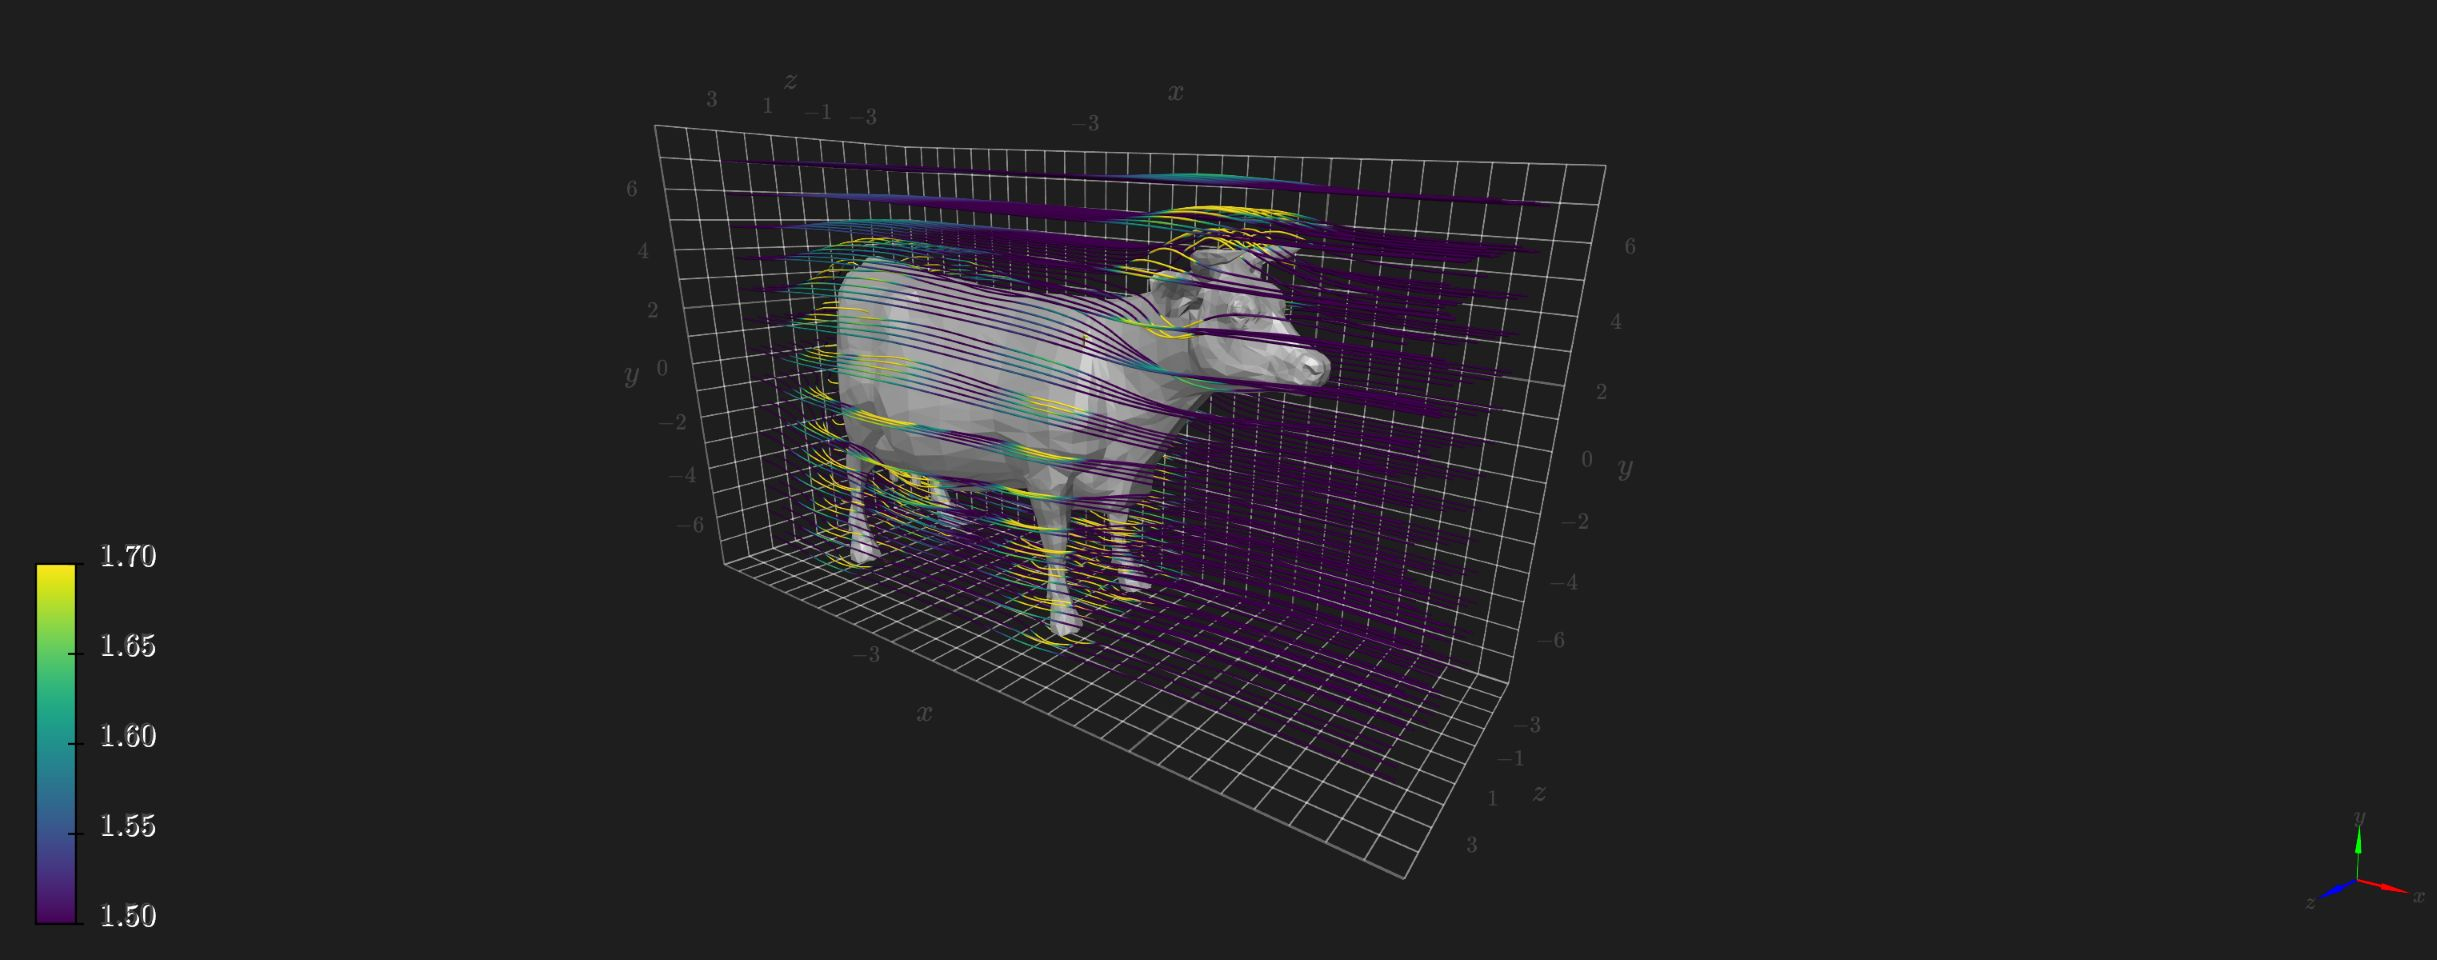